# SHAP Explainability

## Objective
Explain the Ridge Regression AQI model predictions
using SHAP (SHapley Additive exPlanations).

## Why SHAP
- Satisfies project requirement for explainability
- Shows which features drive AQI predictions
- Provides both global and local explanations
- Builds trust in the model for stakeholders

## Model
Ridge Regression (lahore_aqi_ridge_1h v1)
Loaded from Hopsworks Model Registry

## Output
- SHAP summary plot
- SHAP bar plot (global importance)
- SHAP waterfall plot (single prediction)
- SHAP dependence plots (top features)
- Feature importance CSV

In [1]:
import os
import json
import joblib
import warnings
import numpy as np
import pandas as pd
from pathlib import Path

warnings.filterwarnings("ignore")

import shap
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

import hopsworks
from dotenv import load_dotenv

# Plot settings
matplotlib.rcParams["figure.dpi"]     = 150
matplotlib.rcParams["font.size"]      = 11
matplotlib.rcParams["axes.titlesize"] = 13

print("SHAP version    :", shap.__version__)
print("All imports successful.")

SHAP version    : 0.51.0
All imports successful.


In [2]:
load_dotenv()

HOPSWORKS_API_KEY = os.getenv("HOPSWORKS_API_KEY")

if not HOPSWORKS_API_KEY:
    raise ValueError(
        "HOPSWORKS_API_KEY was not found in the .env file."
    )

print("Hopsworks API key loaded successfully.")

Hopsworks API key loaded successfully.


In [3]:
import hopsworks

project = hopsworks.login(
    host="eu-west.cloud.hopsworks.ai",
    project="internship10P",
    api_key_value=HOPSWORKS_API_KEY,
    engine="python",
    cert_folder=r"D:\talha\Pearls_AQI_Predictor\hopsworks-certs"
)

print("Connected to Hopsworks successfully.")
print("Project:", project.name)

2026-08-20 09:35:45,789 INFO: Initializing external client
2026-08-20 09:35:45,789 INFO: Base URL: https://eu-west.cloud.hopsworks.ai:443
2026-08-20 09:35:56,140 INFO: Python Engine initialized.



Logged in to project, explore it here https://eu-west.cloud.hopsworks.ai:443/p/42187
Connected to Hopsworks successfully.
Project: internship10P


In [6]:
print("Loading model from Hopsworks Model Registry...")

mr = project.get_model_registry()

registered_model = mr.get_model(
    name="lahore_aqi_ridge_1h",
    version=1
)

# Download model files locally
DOWNLOAD_DIR = Path("../models/shap_analysis")
DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)

model_path = registered_model.download(
    local_path=str(DOWNLOAD_DIR)
)

print("Downloaded to:", model_path)

# Load the Ridge model
ridge_model = joblib.load(
    Path(model_path) / "ridge_aqi_1h.pkl"
)

print("Model loaded successfully.")
print("Model type:", type(ridge_model))
print("Alpha     :", ridge_model.alpha)

Loading model from Hopsworks Model Registry...


Downloading: 100.000%|██████████| 1457/1457 elapsed<00:00 remaining<?


Downloading: 100.000%|██████████| 1125/1125 elapsed<00:00 remaining<00:00


Downloading: 100.000%|██████████| 138/138 elapsed<00:00 remaining<?


Downloading: 100.000%|██████████| 538/538 elapsed<00:00 remaining<?

Downloaded to: ..\models\shap_analysisfiles)... DONE
Model loaded successfully.
Model type: <class 'sklearn.linear_model._ridge.Ridge'>
Alpha     : 1.0


In [7]:
LOCAL_CSV = Path(
    "../data/processed/lahore/lahore_features_hourly.csv"
)

print("Loading feature data...")

lahore_features = pd.read_csv(
    LOCAL_CSV,
    parse_dates=["datetime"]
)

lahore_features = (
    lahore_features
    .sort_values("datetime")
    .reset_index(drop=True)
)

print("Shape:", lahore_features.shape)
print("Start:", lahore_features["datetime"].min())
print("End  :", lahore_features["datetime"].max())

Loading feature data...
Shape: (22608, 30)
Start: 2024-01-02 00:00:00
End  : 2026-07-31 23:00:00


In [8]:
# Recreate exactly as in notebook 06
lahore_features["target_aqi_1h"] = (
    lahore_features["us_aqi"].shift(-1)
)

lahore_features = (
    lahore_features
    .dropna(subset=["target_aqi_1h"])
    .reset_index(drop=True)
)

FEATURE_COLUMNS = [
    "temperature_2m", "relative_humidity_2m",
    "surface_pressure", "precipitation",
    "cloud_cover", "wind_speed_10m",
    "wind_direction_10m", "pm2_5", "pm10",
    "carbon_monoxide", "nitrogen_dioxide",
    "sulphur_dioxide", "ozone", "us_aqi",
    "hour", "day", "month", "day_of_week",
    "is_weekend", "hour_sin", "hour_cos",
    "month_sin", "month_cos", "aqi_change_rate",
    "aqi_lag_1h", "aqi_lag_24h",
    "aqi_rolling_mean_6h", "aqi_rolling_std_6h",
    "pm25_rolling_mean_6h"
]

n         = len(lahore_features)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

X      = lahore_features[FEATURE_COLUMNS]
y      = lahore_features["target_aqi_1h"]

X_train = X.iloc[:train_end]
X_val   = X.iloc[train_end:val_end]
X_test  = X.iloc[val_end:]
y_test  = y.iloc[val_end:]

print("Data split recreated.")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

Data split recreated.
X_train: (15824, 29)
X_test : (3392, 29)


In [9]:
print("Creating SHAP explainer for Ridge Regression...")

# For linear models use LinearExplainer
# It is the most accurate and fastest for Ridge
explainer = shap.LinearExplainer(
    ridge_model,
    X_train,
    feature_perturbation="interventional"
)

print("Explainer created successfully.")
print("Type:", type(explainer))

Creating SHAP explainer for Ridge Regression...
Explainer created successfully.
Type: <class 'shap.explainers._linear.LinearExplainer'>


In [10]:
# Use test set for SHAP analysis
# Limit to 1000 rows for speed
# Full test set would take too long

SHAP_SAMPLE = min(1000, len(X_test))

X_shap = X_test.iloc[:SHAP_SAMPLE].copy()

print(f"Computing SHAP values for {SHAP_SAMPLE} samples...")
print("This may take 1-2 minutes...")

shap_values = explainer.shap_values(X_shap)

print("SHAP values computed.")
print("SHAP values shape:", shap_values.shape)
# Expected: (1000, 29) — one value per sample per feature

Computing SHAP values for 1000 samples...
This may take 1-2 minutes...
SHAP values computed.
SHAP values shape: (1000, 29)


Generating SHAP Summary Plot (Beeswarm)...


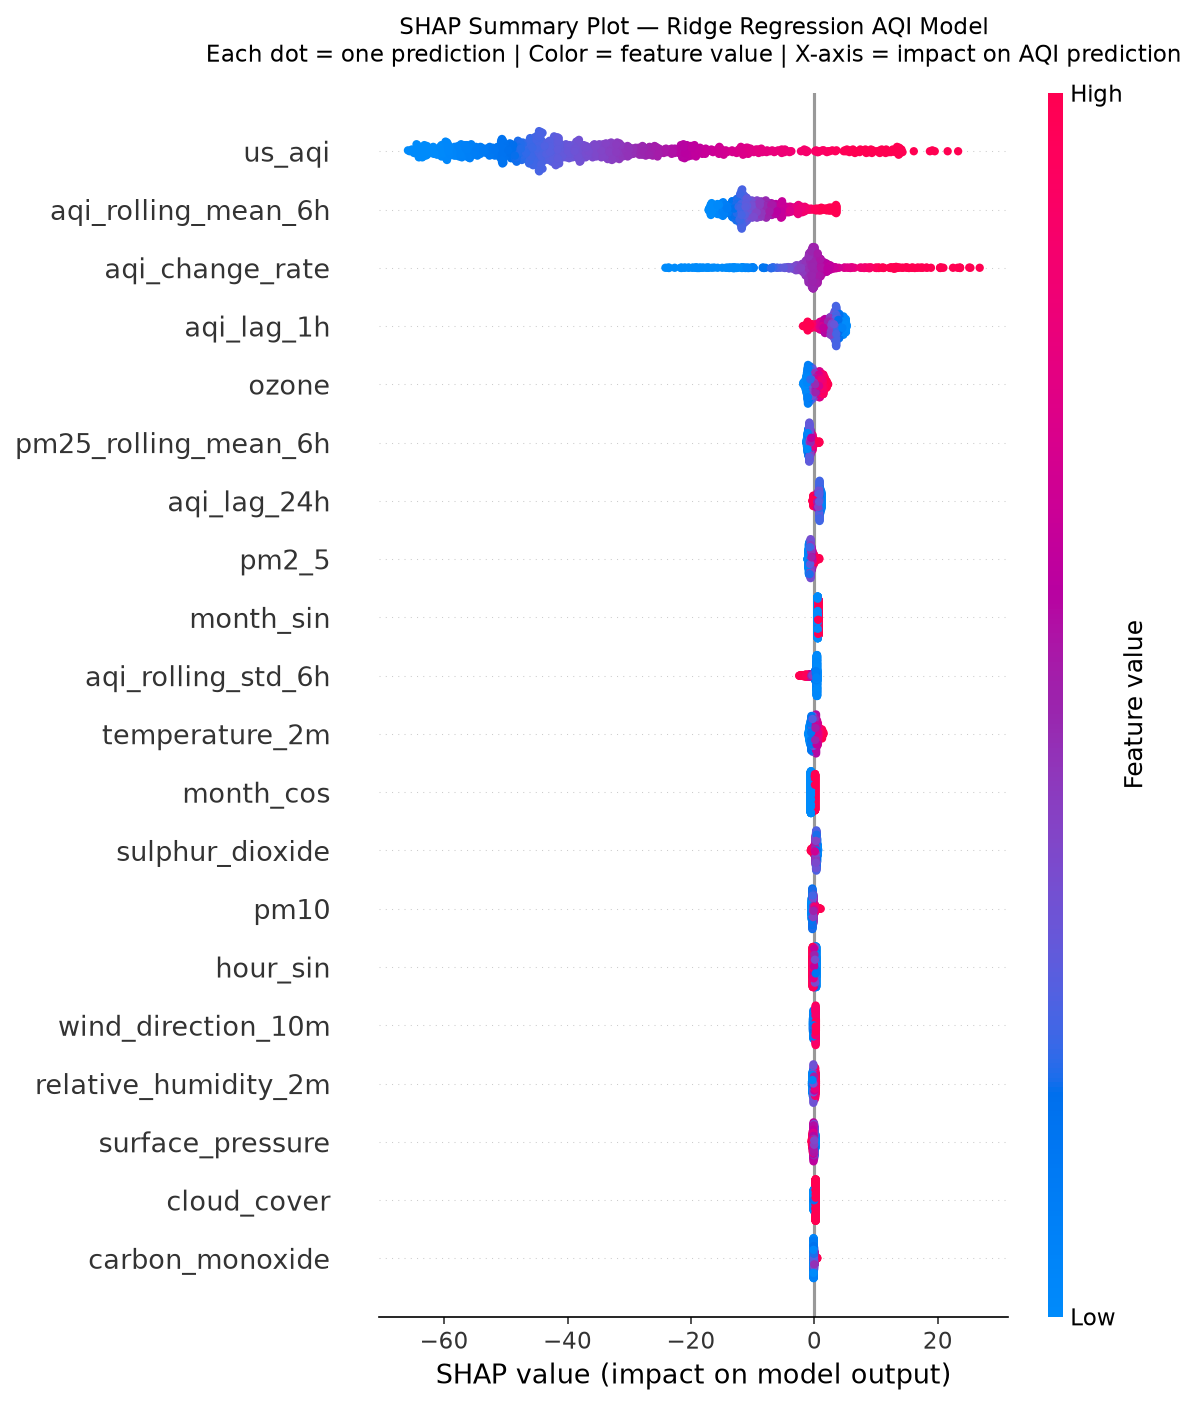

Saved: shap_summary_beeswarm.png


In [14]:
OUTPUT_DIR = Path("../data/processed/lahore")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Generating SHAP Summary Plot (Beeswarm)...")

plt.figure(figsize=(12, 9))

shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=FEATURE_COLUMNS,
    plot_type="dot",
    max_display=20,
    show=False
)

plt.title(
    "SHAP Summary Plot — Ridge Regression AQI Model\n"
    "Each dot = one prediction | "
    "Color = feature value | "
    "X-axis = impact on AQI prediction",
    fontsize=11,
    pad=15
)

plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "shap_summary_beeswarm.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

print("Saved: shap_summary_beeswarm.png")

Generating SHAP Global Feature Importance Bar Plot...


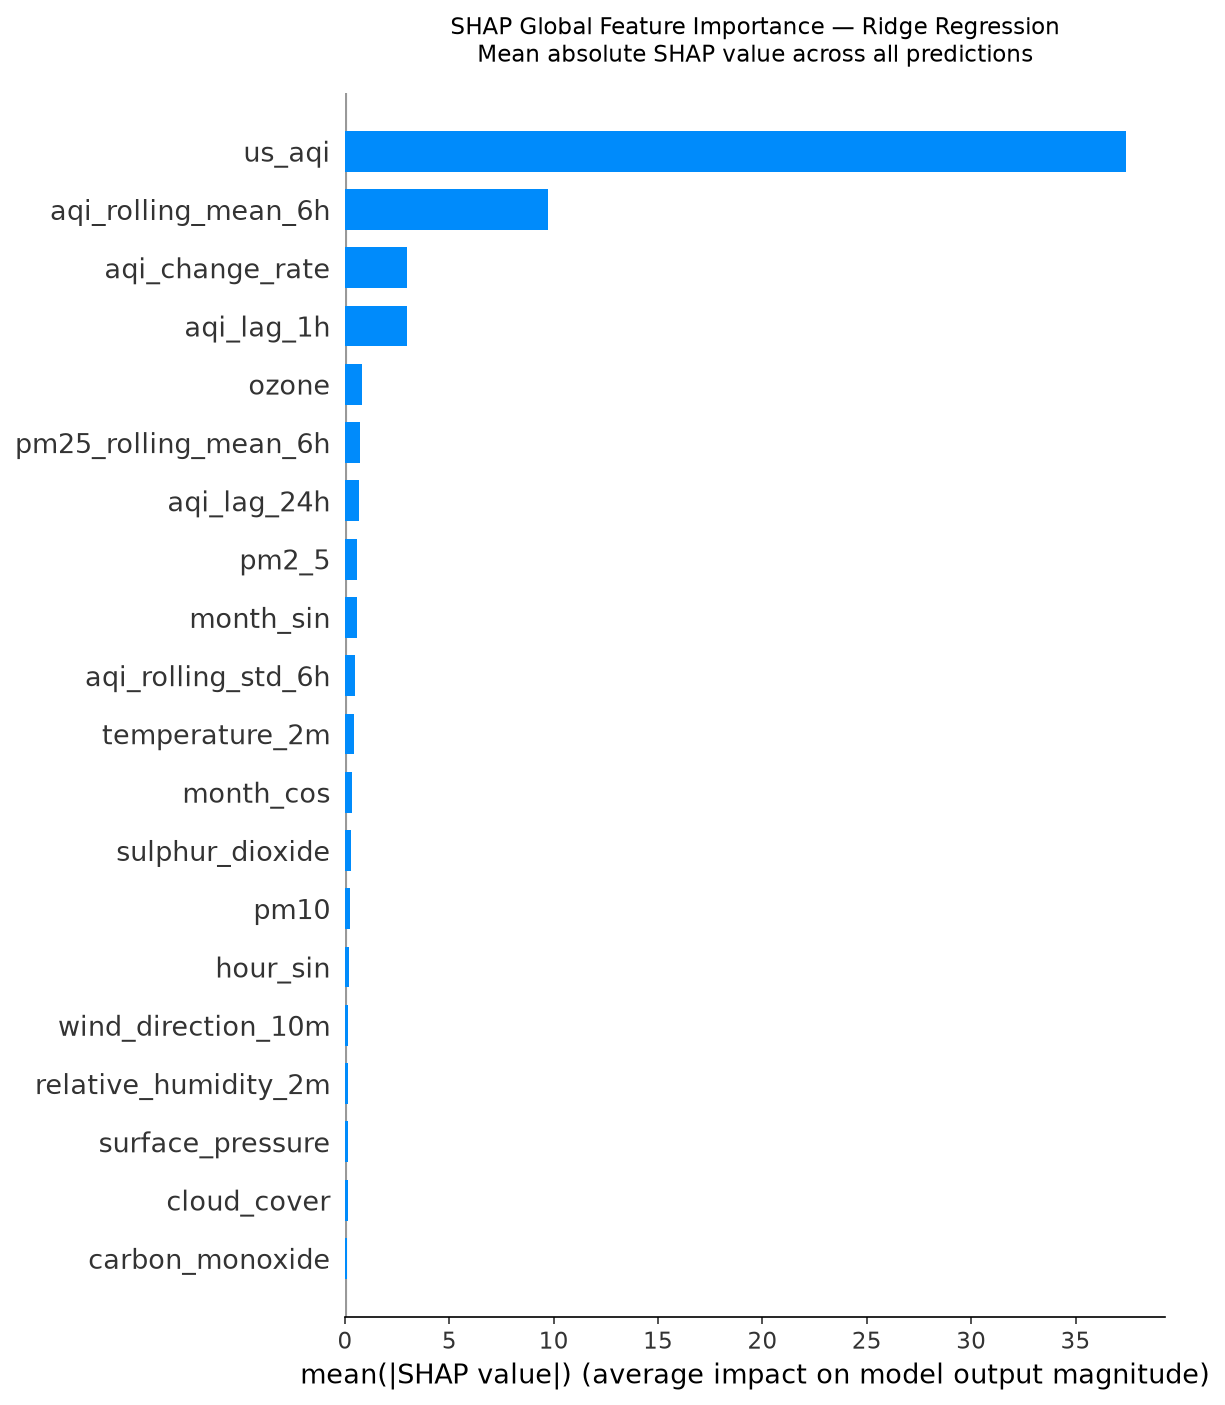

Saved: shap_bar_global_importance.png


In [15]:
print("Generating SHAP Global Feature Importance Bar Plot...")

plt.figure(figsize=(10, 8))

shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=FEATURE_COLUMNS,
    plot_type="bar",
    max_display=20,
    show=False
)

plt.title(
    "SHAP Global Feature Importance — Ridge Regression\n"
    "Mean absolute SHAP value across all predictions",
    fontsize=11,
    pad=15
)

plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "shap_bar_global_importance.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

print("Saved: shap_bar_global_importance.png")

In [16]:
# Mean absolute SHAP value per feature
mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_importance = pd.DataFrame({
    "feature"          : FEATURE_COLUMNS,
    "mean_abs_shap"    : mean_abs_shap,
    "mean_abs_shap_pct": (
        mean_abs_shap / mean_abs_shap.sum() * 100
    )
}).sort_values(
    "mean_abs_shap",
    ascending=False
).reset_index(drop=True)

shap_importance["rank"] = range(1, len(shap_importance) + 1)

print("SHAP Feature Importance — Top 15:")
print("=" * 55)
display(
    shap_importance[
        ["rank", "feature", "mean_abs_shap", "mean_abs_shap_pct"]
    ].head(15)
    .style.format({
        "mean_abs_shap"    : "{:.4f}",
        "mean_abs_shap_pct": "{:.2f}%"
    })
)

# Save to CSV
shap_importance.to_csv(
    OUTPUT_DIR / "shap_feature_importance.csv",
    index=False
)

print("Saved: shap_feature_importance.csv")

SHAP Feature Importance — Top 15:


,rank,feature,mean_abs_shap,mean_abs_shap_pct
0,1,us_aqi,37.4384,63.00%
1,2,aqi_rolling_mean_6h,9.7384,16.39%
2,3,aqi_change_rate,2.9914,5.03%
3,4,aqi_lag_1h,2.9653,4.99%
4,5,ozone,0.8123,1.37%
5,6,pm25_rolling_mean_6h,0.7277,1.22%
6,7,aqi_lag_24h,0.6916,1.16%
7,8,pm2_5,0.5968,1.00%
8,9,month_sin,0.5713,0.96%
9,10,aqi_rolling_std_6h,0.4621,0.78%


Saved: shap_feature_importance.csv


Generating SHAP Waterfall Plot for sample 0...

Sample datetime : 2026-03-12 15:00:00
Actual AQI      : 161.18
Predicted AQI   : 162.26
Error           : 1.08


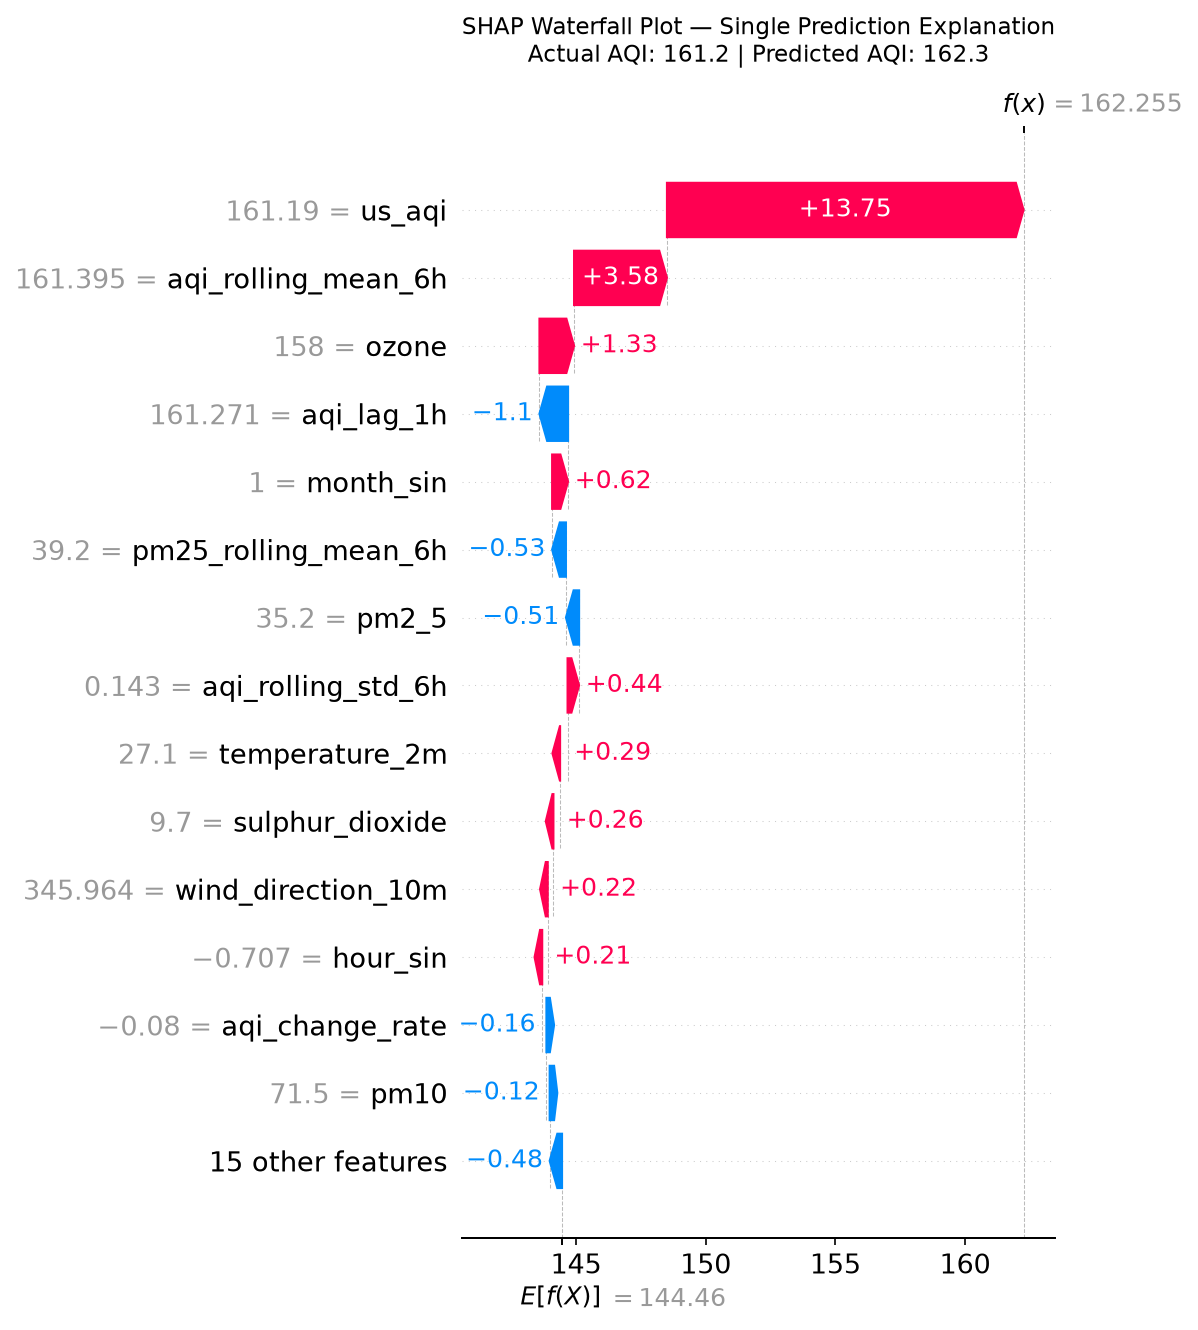

Saved: shap_waterfall_single.png


In [17]:
# Explain one specific prediction in detail
# Choose sample index 0 (first test observation)

SAMPLE_IDX = 0

print(f"Generating SHAP Waterfall Plot for sample {SAMPLE_IDX}...")
print()

actual_aqi    = y_test.iloc[SAMPLE_IDX]
predicted_aqi = ridge_model.predict(
    X_test.iloc[[SAMPLE_IDX]]
)[0]

print(f"Sample datetime : {lahore_features['datetime'].iloc[val_end + SAMPLE_IDX]}")
print(f"Actual AQI      : {actual_aqi:.2f}")
print(f"Predicted AQI   : {predicted_aqi:.2f}")
print(f"Error           : {abs(actual_aqi - predicted_aqi):.2f}")

# Create SHAP Explanation object for waterfall
explanation = shap.Explanation(
    values=shap_values[SAMPLE_IDX],
    base_values=explainer.expected_value,
    data=X_shap.iloc[SAMPLE_IDX].values,
    feature_names=FEATURE_COLUMNS
)

plt.figure(figsize=(12, 8))

shap.waterfall_plot(
    explanation,
    max_display=15,
    show=False
)

plt.title(
    f"SHAP Waterfall Plot — Single Prediction Explanation\n"
    f"Actual AQI: {actual_aqi:.1f} | "
    f"Predicted AQI: {predicted_aqi:.1f}",
    fontsize=11,
    pad=15
)

plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "shap_waterfall_single.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

print("Saved: shap_waterfall_single.png")

Top 3 features by SHAP importance:
  1. us_aqi
  2. aqi_rolling_mean_6h
  3. aqi_change_rate


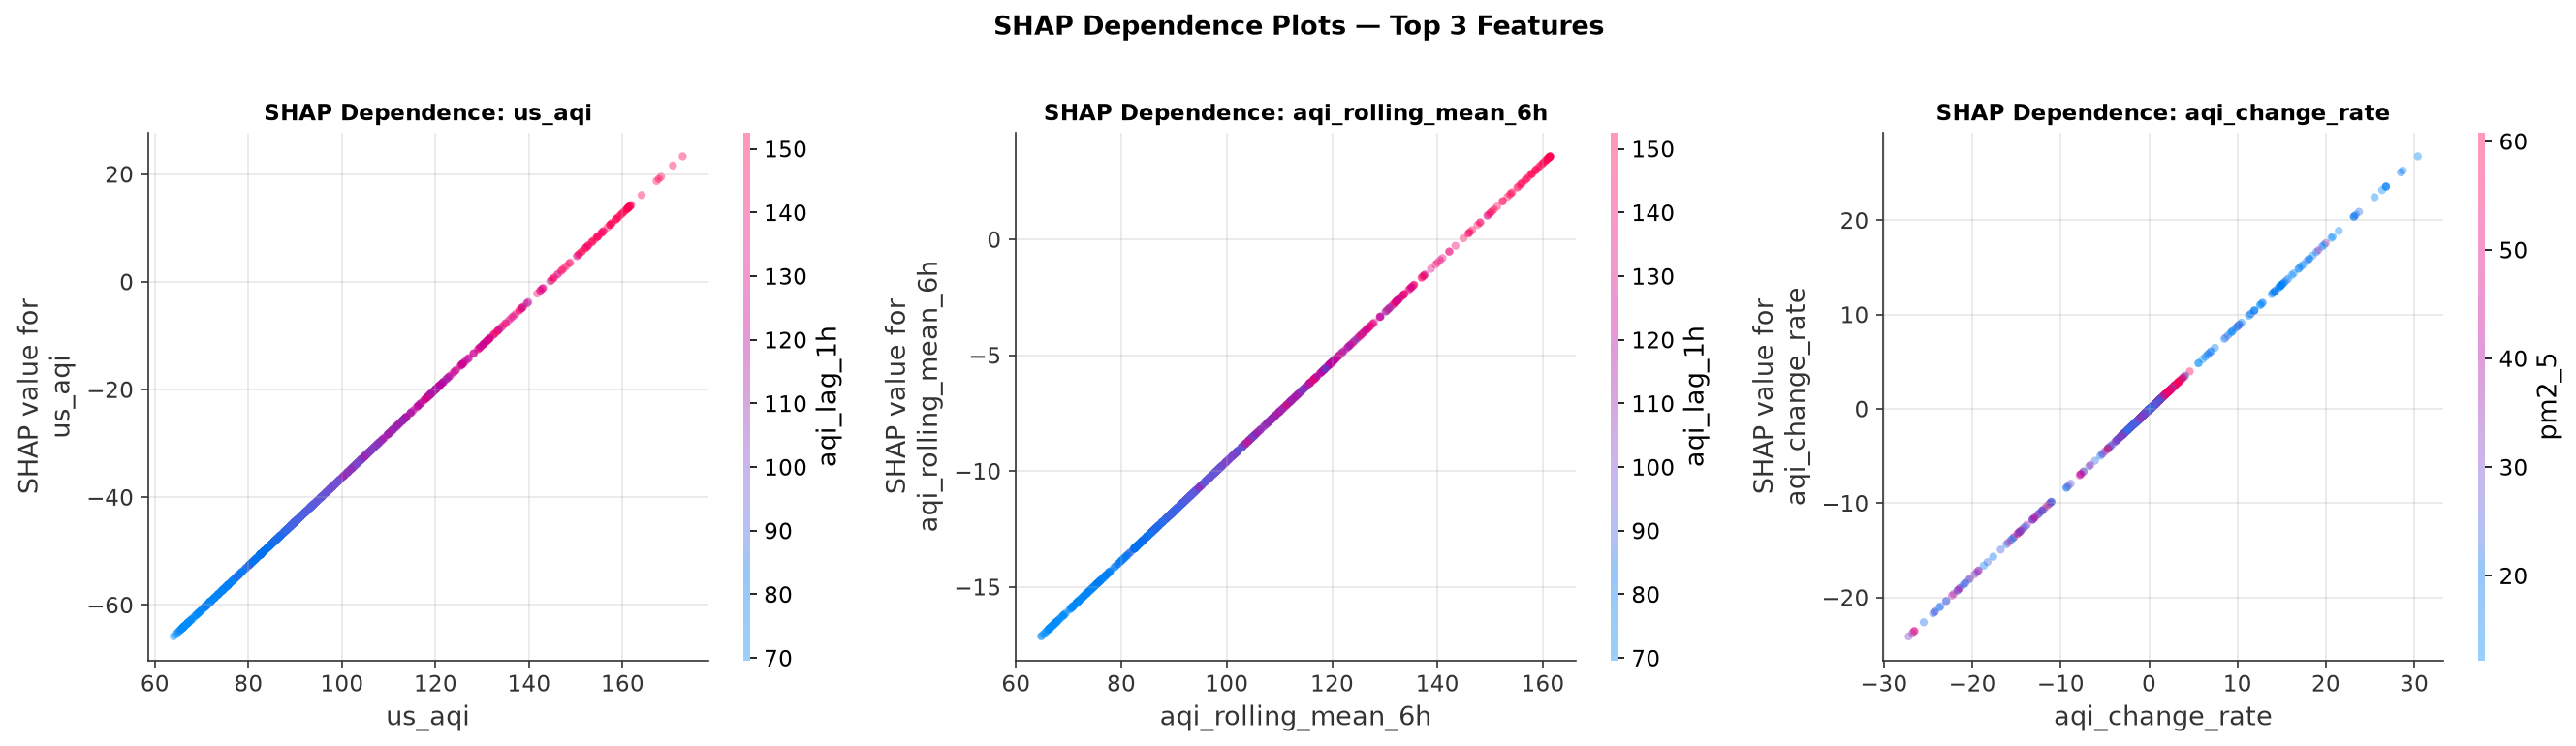

Saved: shap_dependence_top3.png


In [18]:
# Show how top 3 features individually
# affect the AQI prediction

top_3_features = shap_importance["feature"].head(3).tolist()

print("Top 3 features by SHAP importance:")
for i, f in enumerate(top_3_features, 1):
    print(f"  {i}. {f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, feature in enumerate(top_3_features):

    feature_idx = FEATURE_COLUMNS.index(feature)

    shap.dependence_plot(
        ind=feature,
        shap_values=shap_values,
        features=X_shap,
        feature_names=FEATURE_COLUMNS,
        ax=axes[idx],
        show=False,
        alpha=0.4
    )

    axes[idx].set_title(
        f"SHAP Dependence: {feature}",
        fontsize=11,
        fontweight="bold"
    )
    axes[idx].grid(True, alpha=0.3)

plt.suptitle(
    "SHAP Dependence Plots — Top 3 Features",
    fontsize=13,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "shap_dependence_top3.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

print("Saved: shap_dependence_top3.png")

In [19]:
# Interactive force plot for first 100 predictions
print("Generating SHAP Force Plot...")

shap.initjs()

force_plot = shap.force_plot(
    base_value=explainer.expected_value,
    shap_values=shap_values[:100],
    features=X_shap.iloc[:100],
    feature_names=FEATURE_COLUMNS,
    show=False
)

# Save as HTML
force_plot_path = OUTPUT_DIR / "shap_force_plot.html"

shap.save_html(
    str(force_plot_path),
    force_plot
)

print("Saved: shap_force_plot.html")
print("Open this file in a browser for interactive exploration.")

Generating SHAP Force Plot...


Saved: shap_force_plot.html
Open this file in a browser for interactive exploration.


In [21]:
print()
print("=" * 60)
print("NOTEBOOK 08 COMPLETE — SHAP EXPLAINABILITY SUMMARY")
print("=" * 60)
print()
print("Model explained : Ridge Regression (lahore_aqi_ridge_1h v1)")
print("Samples analyzed:", SHAP_SAMPLE)
print()
print("Top 10 Features by SHAP Importance:")
print("-" * 45)

for _, row in shap_importance.head(10).iterrows():
    bar = "█" * int(row["mean_abs_shap_pct"] / 2)
    print(
        f"  {int(row['rank']):2d}. "
        f"{row['feature']:28s} "
        f"{row['mean_abs_shap_pct']:5.2f}%  {bar}"
    )

print()
print("Saved Files:")
print("  ../data/processed/lahore/shap_summary_beeswarm.png")
print("  ../data/processed/lahore/shap_bar_global_importance.png")
print("  ../data/processed/lahore/shap_feature_importance.csv")
print("  ../data/processed/lahore/shap_waterfall_single.png")
print("  ../data/processed/lahore/shap_dependence_top3.png")
print("  ../data/processed/lahore/shap_force_plot.html")
print()
print("Project Requirement Satisfied:")
print("  SHAP feature importance explanations ✅")
print()
print("Next Step:")
print("  09_forecasting_pipeline.ipynb")
print("  72-hour AQI forecast for next 3 days")
print("=" * 60)


NOTEBOOK 08 COMPLETE — SHAP EXPLAINABILITY SUMMARY

Model explained : Ridge Regression (lahore_aqi_ridge_1h v1)
Samples analyzed: 1000

Top 10 Features by SHAP Importance:
---------------------------------------------
   1. us_aqi                       63.00%  ███████████████████████████████
   2. aqi_rolling_mean_6h          16.39%  ████████
   3. aqi_change_rate               5.03%  ██
   4. aqi_lag_1h                    4.99%  ██
   5. ozone                         1.37%  
   6. pm25_rolling_mean_6h          1.22%  
   7. aqi_lag_24h                   1.16%  
   8. pm2_5                         1.00%  
   9. month_sin                     0.96%  
  10. aqi_rolling_std_6h            0.78%  

Saved Files:
  ../data/processed/lahore/shap_summary_beeswarm.png
  ../data/processed/lahore/shap_bar_global_importance.png
  ../data/processed/lahore/shap_feature_importance.csv
  ../data/processed/lahore/shap_waterfall_single.png
  ../data/processed/lahore/shap_dependence_top3.png
  ../data/pro